# 24 — Residual Connections

Residual connections let a block learn a correction to its input instead of an entirely new mapping. This notebook turns the ResNet idea from [Notebook 23](./23_from_lenet_to_modern_cnns.ipynb) into explicit NumPy forward and backward passes.

## Learning objectives

- distinguish a residual branch from its shortcut;
- implement an identity residual block;
- derive gradient accumulation at residual addition;
- verify residual-block gradients numerically;
- explain why a residual block can represent the identity mapping easily;
- recognize when a projection shortcut is required;
- visualize how shortcuts provide a direct gradient path.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import eval_numerical_gradient_array, relative_error
from cs231n_practice.layers import (
    affine_backward,
    affine_forward,
    affine_relu_backward,
    affine_relu_forward,
)

SEED = 42


## 1. The residual-block equation

A block with an identity shortcut computes

$$
Y=F(X;W)+X.
$$

$F$ is the **residual branch**, containing learned transformations. The direct $X$ term is the **shortcut** or **skip connection**. Both tensors must have exactly the same shape before elementwise addition.

In this notebook the residual branch is

$$
F(X)=\bigl(\mathrm{ReLU}(XW_1+b_1)\bigr)W_2+b_2.
$$

The hidden width may differ from the input width, but the second affine layer must return to the input dimension so $F(X)+X$ is valid.


### Exercise 1 — Implement the identity residual forward pass

Complete the residual branch using the reusable layer functions, verify that its output shape matches `x`, then add the shortcut. Cache both branch operations for backpropagation.


In [29]:
def residual_forward(x, W1, b1, W2, b2):
    """Compute affine-ReLU-affine residual branch plus identity shortcut."""
    # compute hidden activations and the residual branch.

    ## option 1 - from scratch
    # hidden = np.maximum(0.0, x@W1+b1)
    # hidden_cache = (x, W1)
    # residual = hidden@W2+b2
    # residual_cache = (hidden, W2)

    # option 2 - re-use existing previously implemented functions
    hidden, hidden_cache = affine_relu_forward(x, W1, b1)
    residual, residual_cache = affine_forward(hidden, W2, b2)

    if residual.shape != x.shape:
        raise ValueError("residual branch output must have the same shape as x")
    output = x + residual
    return output, (hidden_cache, residual_cache)


generator = np.random.default_rng(SEED)
example_x = generator.normal(size=(3, 4))
example_W1 = generator.normal(scale=0.2, size=(4, 6))
example_b1 = generator.normal(scale=0.1, size=6)
example_W2 = generator.normal(scale=0.2, size=(6, 4))
example_b2 = generator.normal(scale=0.1, size=4)
example_output, example_cache = residual_forward(
    example_x, example_W1, example_b1, example_W2, example_b2
)
assert example_output.shape == example_x.shape
print("Input shape:", example_x.shape, "Output shape:", example_output.shape)


Input shape: (3, 4) Output shape: (3, 4)


## 2. Backpropagation through addition

Suppose an upstream gradient $dY$ reaches

$$
Y=F(X)+X.
$$

The addition sends the same $dY$ into both incoming paths. The shortcut contributes

$$
dX_{shortcut}=dY,
$$

while backpropagation through $F$ produces $dX_{branch}$. Since both paths originate at $X$, their gradients accumulate:

$$
dX=dX_{shortcut}+dX_{branch}=dY+dX_{branch}.
$$

This is the same gradient-accumulation rule used whenever one value influences the loss through multiple computational-graph paths.


### Exercise 2 — Implement the residual backward pass

Backpropagate through the second affine layer and then through the affine-ReLU layer. Add the identity shortcut gradient to the branch gradient before returning `dx`.


In [30]:
def residual_backward(dout, cache):
    """Backpropagate through a residual branch and identity shortcut."""
    hidden_cache, residual_cache = cache

    # backpropagate through the residual branch.

    ## option 1 - from scratch
    # hidden, W2 = residual_cache
    # x, W1 = hidden_cache
    # dhidden = dout @ W2.T
    # dW2 = hidden.T @ dout
    # db2 = np.sum(dout, axis=0)
    # dhidden_relu = dhidden * (hidden > 0)
    # dx_branch = dhidden_relu @ W1.T
    # dW1 = x.T @ dhidden_relu
    # db1 = np.sum(dhidden_relu, axis=0)

    # option 2 - re-use existing previously implemented functions
    dhidden, dW2, db2 = affine_backward(dout, residual_cache)
    dx_branch, dW1, db1 = affine_relu_backward(dhidden, hidden_cache)

    # accumulate branch and shortcut contributions.
    dx = dx_branch + dout
    return dx, dW1, db1, dW2, db2


example_dout = generator.normal(size=example_output.shape)
analytical_gradients = residual_backward(example_dout, example_cache)
for name, gradient, expected_shape in zip(
    ("dx", "dW1", "db1", "dW2", "db2"),
    analytical_gradients,
    (example_x.shape, example_W1.shape, example_b1.shape, example_W2.shape, example_b2.shape),
):
    assert gradient.shape == expected_shape, f"{name} has the wrong shape"


## 3. Numerical gradient verification

The addition itself is simple, but it is easy to forget that `dx` needs contributions from both paths. Numerical checking verifies the entire composite block.


In [32]:
numerical_gradients = (
    eval_numerical_gradient_array(
        lambda candidate: residual_forward(
            candidate, example_W1, example_b1, example_W2, example_b2
        )[0],
        example_x,
        example_dout,
    ),
    eval_numerical_gradient_array(
        lambda candidate: residual_forward(
            example_x, candidate, example_b1, example_W2, example_b2
        )[0],
        example_W1,
        example_dout,
    ),
    eval_numerical_gradient_array(
        lambda candidate: residual_forward(
            example_x, example_W1, candidate, example_W2, example_b2
        )[0],
        example_b1,
        example_dout,
    ),
    eval_numerical_gradient_array(
        lambda candidate: residual_forward(
            example_x, example_W1, example_b1, candidate, example_b2
        )[0],
        example_W2,
        example_dout,
    ),
    eval_numerical_gradient_array(
        lambda candidate: residual_forward(
            example_x, example_W1, example_b1, example_W2, candidate
        )[0],
        example_b2,
        example_dout,
    ),
)
gradient_errors = {
    name: relative_error(analytical, numerical)
    for name, analytical, numerical in zip(
        ("dx", "dW1", "db1", "dW2", "db2"),
        analytical_gradients,
        numerical_gradients,
    )
}
print(gradient_errors)
assert all(error < 1e-6 for error in gradient_errors.values())


{'dx': 2.8171939106830007e-11, 'dW1': 7.950557431277591e-11, 'db1': 3.4009473108200113e-08, 'dW2': 4.030637892943945e-10, 'db2': 6.230044924921776e-12}


## 4. The identity mapping is easy to represent

If the residual branch outputs zero, then

$$
Y=0+X=X.
$$

A residual block can therefore preserve its input by driving the final residual transformation toward zero. A plain stack must instead learn the complete identity transformation through all of its layers. This does not mean every trained residual block becomes identity; it means identity is an accessible reference behavior.

### Exercise 3 — Construct an exact identity block

Set the second residual affine layer's weights and bias so the residual branch is exactly zero for every input. Verify both the forward output and the input gradient.


In [34]:
# choose W2 and b2 that make the residual branch exactly zero.
identity_W2 = np.zeros(example_W2.shape)
identity_b2 =  np.zeros(example_b2.shape)
identity_output, identity_cache = residual_forward(
    example_x, example_W1, example_b1, identity_W2, identity_b2
)
identity_dx, *_ = residual_backward(example_dout, identity_cache)

np.testing.assert_allclose(identity_output, example_x)
np.testing.assert_allclose(identity_dx, example_dout)
print("Zero residual branch gives exact identity forward and backward behavior.")


Zero residual branch gives exact identity forward and backward behavior.


## 5. A simplified view of gradient flow

For a linear plain layer $X_{l+1}=A_lX_l$, backward propagation repeatedly multiplies by $A_l^T$. A simplified residual layer $X_{l+1}=X_l+A_lX_l$ instead multiplies by $(I+A_l)^T$. The identity term provides a direct contribution at every block.

This toy experiment is not a realistic neural network and does not prove that residual gradients can never vanish or explode. It isolates the shortcut's algebraic effect.


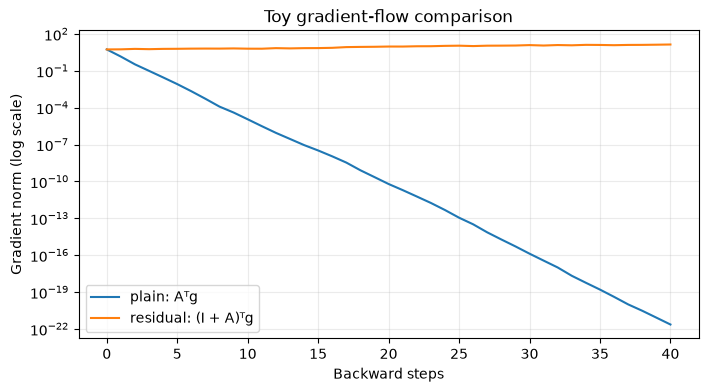

In [35]:
depth = 40
width = 32
flow_generator = np.random.default_rng(SEED + 1)
matrices = flow_generator.normal(scale=0.05, size=(depth, width, width))
upstream = flow_generator.normal(size=width)
identity = np.eye(width)

plain_gradient = upstream.copy()
residual_gradient = upstream.copy()
plain_norms = [np.linalg.norm(plain_gradient)]
residual_norms = [np.linalg.norm(residual_gradient)]
for matrix in matrices[::-1]:
    plain_gradient = matrix.T @ plain_gradient
    residual_gradient = (identity + matrix).T @ residual_gradient
    plain_norms.append(np.linalg.norm(plain_gradient))
    residual_norms.append(np.linalg.norm(residual_gradient))

plt.figure(figsize=(8, 4))
plt.semilogy(plain_norms, label="plain: Aᵀg")
plt.semilogy(residual_norms, label="residual: (I + A)ᵀg")
plt.xlabel("Backward steps")
plt.ylabel("Gradient norm (log scale)")
plt.title("Toy gradient-flow comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 6. Projection shortcuts

An identity shortcut is impossible when $F(X)$ and $X$ have different feature dimensions. A projection shortcut learns

$$
Y=F(X)+XW_s+b_s.
$$

In CNNs, $W_s$ is commonly a $1\times1$ convolution, possibly with stride greater than one when spatial downsampling is also required. The projection is not merely padding syntax: it contains learned parameters and its own backward path.

### Exercise 4 — Implement a feature projection shortcut

For matrix-shaped activations, use an affine layer as the shortcut projection. The residual branch output is provided directly here so the exercise stays focused on shape compatibility.


In [ ]:
projection_x = generator.normal(size=(3, 4))
projection_residual = generator.normal(size=(3, 7))
projection_weights = generator.normal(scale=0.2, size=(4, 7))
projection_bias = np.zeros(7)

# project x, check compatibility, and add the two paths.
projected_shortcut, projection_cache = affine_forward(
    projection_x, projection_weights, projection_bias
)
projection_output = projection_residual + projected_shortcut

assert projected_shortcut.shape == projection_residual.shape
assert projection_output.shape == (3, 7)
np.testing.assert_allclose(projection_output, projection_residual + projected_shortcut)


## 7. Block ordering

The original ResNet commonly used a post-activation pattern resembling

```text
conv -> normalization -> ReLU -> conv -> normalization -> add -> ReLU
```

A later pre-activation design moved normalization and ReLU before convolutions, leaving a cleaner identity route through block boundaries. The exact ordering affects optimization and is part of the architecture—not an interchangeable formatting choice. Our small affine block isolates residual addition and does not reproduce every detail of either ResNet design.

## Reflection

1. What is the difference between the residual branch and the shortcut?
2. Why must gradients from the two paths be added at $X$?
3. What gradient does the identity shortcut contribute?
4. Why is the identity mapping easy for a residual block to represent?
5. Does a shortcut guarantee that gradients can never vanish or explode?
6. When is a projection shortcut necessary?
7. Why does a projection shortcut introduce additional gradients and parameters?
8. What limitation prevents our current `SmallConvNet` from being called a residual network?

## Primary source

- He et al., [Deep Residual Learning for Image Recognition](https://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf).


1. The residual branch applies learned transformations to compute a correction $F(X)$. The shortcut carries $X$ directly, or applies a learned projection when its shape must change.
2. $X$ influences the output through both the residual branch and the shortcut. By the multivariable chain rule, its gradient is the sum of the contributions from every path.
3. An identity shortcut contributes the upstream gradient $dY$ directly to $dX$.
4. If the residual branch learns $F(X)=0$, the block immediately becomes $Y=X$. It therefore does not need its stacked learned layers to reproduce the complete identity transformation.
5. No. The identity term provides a direct gradient contribution, but the residual-branch Jacobians still affect the accumulated gradient. Poor scaling, initialization, or great depth can still produce unstable gradients.
6. A projection shortcut is necessary when the residual-branch output and shortcut input have different channel counts or spatial dimensions, because elementwise addition requires matching shapes.
7. The projection contains learned weights and usually a bias or normalization parameters. Backpropagation must therefore compute their gradients and propagate the shortcut gradient through the projection to $X$.
8. `SmallConvNet` is a single sequential chain and has no shortcut additions around learned blocks, so it is not a residual network.